# HW12 – Временные ряды: temporal split, baseline-модели и GRU-прогноз

**Датасет**: `S12-hw-dataset.csv` — почасовой временной ряд (4 320 наблюдений, 180 дней)  
**Задача**: прогнозирование следующего значения (`horizon=1`)  
**Эксперименты**: B1 (naive-last), B2 (moving-average), B3 (ridge-lag-features), R1 (gru-forecast)

## 0. Импорты, seed, устройство

In [8]:
import os, json, csv, random, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Seed ──────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}  |  pandas: {pd.__version__}')

ART = './artifacts'
os.makedirs(f'{ART}/figures', exist_ok=True)

Device: cpu
PyTorch: 2.2.2  |  pandas: 3.0.1


## 1. Загрузка данных и первичный анализ

In [9]:
df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('=== Sanity check ===')
print(f'Shape:      {df.shape}')
print(f'Date range: {df["date"].min()}  →  {df["date"].max()}')
print(f'Freq:       hourly (inferred)')
print(f'Nulls:\n{df.isnull().sum()}')
print(f'\nTarget stats:')
print(df['target'].describe().round(3))

=== Sanity check ===
Shape:      (4320, 2)
Date range: 2025-01-01 00:00:00  →  2025-06-29 23:00:00
Freq:       hourly (inferred)
Nulls:
date      0
target    0
dtype: int64

Target stats:
count    4320.000
mean      135.606
std        21.385
min        69.100
25%       120.538
50%       135.835
75%       150.625
max       210.100
Name: target, dtype: float64


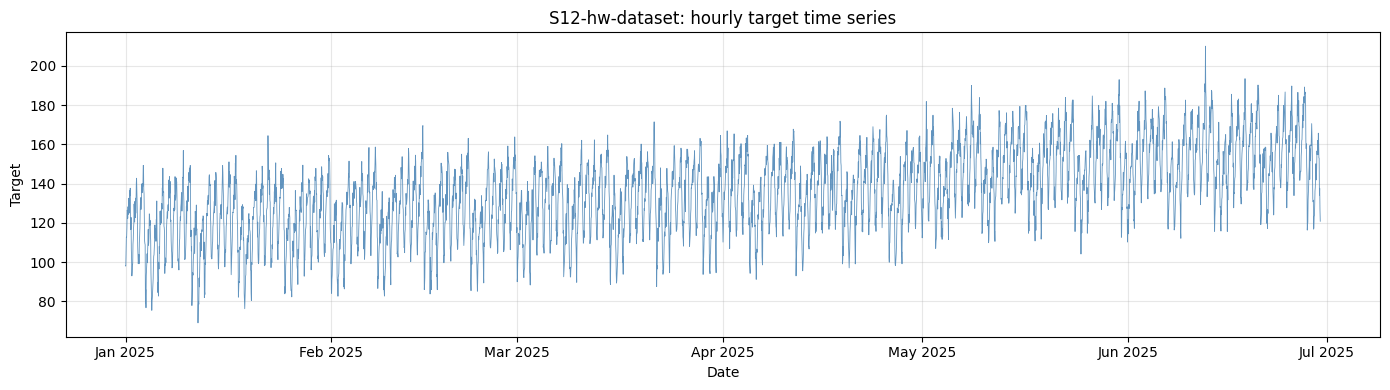

Комментарий: ряд демонстрирует выраженную суточную сезонность (24-часовой цикл), слабый восходящий тренд, без значимых пропусков и явных выбросов.


In [10]:
# Базовый график временного ряда
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['target'], color='steelblue', linewidth=0.6, alpha=0.85)
ax.set_title('S12-hw-dataset: hourly target time series', fontsize=12)
ax.set_xlabel('Date'); ax.set_ylabel('Target')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ART}/figures/series_raw.png', dpi=100, bbox_inches='tight')
plt.show()
print('Комментарий: ряд демонстрирует выраженную суточную сезонность (24-часовой цикл),'
      ' слабый восходящий тренд, без значимых пропусков и явных выбросов.')

## 2. Temporal Split (train / validation / test)

In [11]:
# Разбиение по времени: 70% train / 15% val / 15% test
N = len(df)
n_train = int(N * 0.70)   # ~3024
n_val   = int(N * 0.15)   # ~648
n_test  = N - n_train - n_val  # ~648

df_train = df.iloc[:n_train].copy()
df_val   = df.iloc[n_train:n_train + n_val].copy()
df_test  = df.iloc[n_train + n_val:].copy()

print('=== Temporal split ===')
print(f'Train:  {len(df_train):5d} rows  {df_train["date"].min().date()} → {df_train["date"].max().date()}')
print(f'Val:    {len(df_val):5d} rows  {df_val["date"].min().date()} → {df_val["date"].max().date()}')
print(f'Test:   {len(df_test):5d} rows  {df_test["date"].min().date()} → {df_test["date"].max().date()}')

print('\nПочему random split некорректен:')
print('  При случайном перемешивании модель может видеть значения из середины ряда')
print('  и предсказывать прошлое, что создаёт утечку из будущего (data leakage).')
print('  Реальная задача — предсказывать будущие значения по прошлым, поэтому')
print('  валидация должна строго идти ПОСЛЕ обучающей части по времени.')

=== Temporal split ===
Train:   3024 rows  2025-01-01 → 2025-05-06
Val:      648 rows  2025-05-07 → 2025-06-02
Test:     648 rows  2025-06-03 → 2025-06-29

Почему random split некорректен:
  При случайном перемешивании модель может видеть значения из середины ряда
  и предсказывать прошлое, что создаёт утечку из будущего (data leakage).
  Реальная задача — предсказывать будущие значения по прошлым, поэтому
  валидация должна строго идти ПОСЛЕ обучающей части по времени.


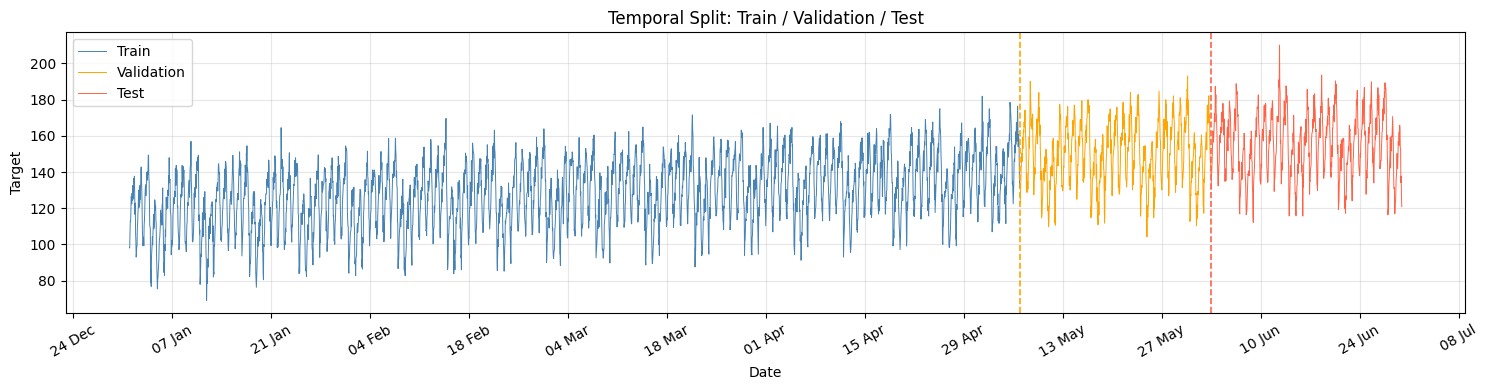

In [12]:
# Визуализация split
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df_train['date'], df_train['target'], color='steelblue',  linewidth=0.7, label='Train')
ax.plot(df_val['date'],   df_val['target'],   color='orange',     linewidth=0.7, label='Validation')
ax.plot(df_test['date'],  df_test['target'],  color='tomato',     linewidth=0.7, label='Test')
ax.axvline(df_val['date'].iloc[0],  color='orange', linestyle='--', linewidth=1.2)
ax.axvline(df_test['date'].iloc[0], color='tomato',  linestyle='--', linewidth=1.2)
ax.set_title('Temporal Split: Train / Validation / Test', fontsize=12)
ax.set_xlabel('Date'); ax.set_ylabel('Target')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ART}/figures/series_split.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Метрики

In [13]:
def mape(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / (np.abs(y_true) + eps))) * 100

def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_v = mape(y_true, y_pred)
    return mae, rmse, mape_v

print('Metric helpers ready.')

Metric helpers ready.


## 4. B1 – naive-last baseline

In [14]:
# B1: прогноз = последнее известное значение
# На validation: для каждого шага предсказываем значение предыдущего шага
val_series  = df_val['target'].values
test_series = df_test['target'].values
# последнее значение train / последнее значение val
last_train = df_train['target'].iloc[-1]
last_val   = df_val['target'].iloc[-1]

# На validation: y[t-1] → y[t]
pred_b1_val = np.concatenate([[last_train], val_series[:-1]])
mae_b1_val, rmse_b1_val, mape_b1_val = compute_metrics(val_series, pred_b1_val)

print(f'B1 val  | MAE={mae_b1_val:.4f}  RMSE={rmse_b1_val:.4f}  MAPE={mape_b1_val:.2f}%')

B1 val  | MAE=6.4448  RMSE=8.2010  MAPE=4.40%


## 5. B2 – moving-average baseline

In [15]:
# B2: скользящее среднее по окну 24 часа (один суточный цикл)
WINDOW_MA = 24

# Для корректного MA на val/test — используем хвост train как историю
all_series = df['target'].values
train_end  = n_train
val_end    = n_train + n_val

def moving_average_forecast(series, history_end, n_steps, window):
    preds = []
    buf = list(series[history_end - window: history_end])
    for i in range(n_steps):
        pred = np.mean(buf[-window:])
        preds.append(pred)
        buf.append(series[history_end + i])  # добавляем факт (без lookahead на val)
    return np.array(preds)

pred_b2_val  = moving_average_forecast(all_series, train_end, n_val,  WINDOW_MA)
mae_b2_val, rmse_b2_val, mape_b2_val = compute_metrics(val_series, pred_b2_val)

print(f'B2 val  | MAE={mae_b2_val:.4f}  RMSE={rmse_b2_val:.4f}  MAPE={mape_b2_val:.2f}%  (window={WINDOW_MA}h)')

B2 val  | MAE=13.3980  RMSE=16.1699  MAPE=9.20%  (window=24h)


## 6. Признаки для B3 и GRU-baseline

In [16]:
def build_features(df_full):
    """Строит lag- и rolling-признаки без утечки из будущего."""
    d = df_full.copy()
    d = d.sort_values('date').reset_index(drop=True)
    
    # Lag-признаки
    d['lag_1']   = d['target'].shift(1)
    d['lag_7']   = d['target'].shift(7)    # 7 часов назад
    d['lag_14']  = d['target'].shift(14)   # 14 часов назад
    d['lag_24']  = d['target'].shift(24)   # сутки назад
    d['lag_168'] = d['target'].shift(168)  # неделя назад (168 часов)
    
    # Rolling-признаки (shift(1) чтобы не включать текущее значение)
    d['rolling_mean_7']  = d['target'].shift(1).rolling(7).mean()
    d['rolling_std_7']   = d['target'].shift(1).rolling(7).std()
    d['rolling_mean_24'] = d['target'].shift(1).rolling(24).mean()
    d['rolling_std_24']  = d['target'].shift(1).rolling(24).std()
    
    # Календарные признаки
    d['hour']        = d['date'].dt.hour
    d['dayofweek']   = d['date'].dt.dayofweek
    d['dayofmonth']  = d['date'].dt.day
    d['month']       = d['date'].dt.month
    d['is_weekend']  = (d['dayofweek'] >= 5).astype(int)
    # Циклические (sin/cos) для часа и дня недели
    d['hour_sin']    = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos']    = np.cos(2 * np.pi * d['hour'] / 24)
    d['dow_sin']     = np.sin(2 * np.pi * d['dayofweek'] / 7)
    d['dow_cos']     = np.cos(2 * np.pi * d['dayofweek'] / 7)
    
    return d

df_feat = build_features(df)

FEATURE_COLS = [
    'lag_1', 'lag_7', 'lag_14', 'lag_24', 'lag_168',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24', 'rolling_std_24',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'month'
]
TARGET = 'target'

# Удаляем строки с NaN (из-за лагов/rolling)
df_feat_clean = df_feat.dropna(subset=FEATURE_COLS + [TARGET]).copy()
print(f'Features built: {len(FEATURE_COLS)} cols  |  valid rows: {len(df_feat_clean)}')

# Разбиение по индексу original (temporal)
train_mask = df_feat_clean['date'] < df_val['date'].iloc[0]
val_mask   = (df_feat_clean['date'] >= df_val['date'].iloc[0]) & \
             (df_feat_clean['date'] < df_test['date'].iloc[0])
test_mask  = df_feat_clean['date'] >= df_test['date'].iloc[0]

X_train_f = df_feat_clean.loc[train_mask, FEATURE_COLS].values
y_train_f = df_feat_clean.loc[train_mask, TARGET].values
X_val_f   = df_feat_clean.loc[val_mask,   FEATURE_COLS].values
y_val_f   = df_feat_clean.loc[val_mask,   TARGET].values
X_test_f  = df_feat_clean.loc[test_mask,  FEATURE_COLS].values
y_test_f  = df_feat_clean.loc[test_mask,  TARGET].values

print(f'X_train: {X_train_f.shape}  X_val: {X_val_f.shape}  X_test: {X_test_f.shape}')

# Масштабирование: fit только на train
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train_f)
X_val_s   = scaler_X.transform(X_val_f)
X_test_s  = scaler_X.transform(X_test_f)

print('Scaling done (fit on train only). No leakage from val/test.')

Features built: 15 cols  |  valid rows: 4152
X_train: (2856, 15)  X_val: (648, 15)  X_test: (648, 15)
Scaling done (fit on train only). No leakage from val/test.


## 7. B3 – Ridge на лаговых и rolling-признаках

In [17]:
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train_f)

pred_b3_val  = ridge.predict(X_val_s)
mae_b3_val, rmse_b3_val, mape_b3_val = compute_metrics(y_val_f, pred_b3_val)

print(f'B3 val  | MAE={mae_b3_val:.4f}  RMSE={rmse_b3_val:.4f}  MAPE={mape_b3_val:.2f}%')
print(f'        | alpha=10, {len(FEATURE_COLS)} features (lag, rolling, calendar)')

B3 val  | MAE=5.1194  RMSE=6.4184  MAPE=3.39%
        | alpha=10, 15 features (lag, rolling, calendar)


## 8. R1 – GRU forecast

In [18]:
# ── Параметры GRU ─────────────────────────────────────────────────────────────
WINDOW_SIZE = 48   # 48 часов истории
HORIZON     = 1    # прогнозируем 1 шаг вперёд
HIDDEN_SIZE = 64
NUM_LAYERS  = 2
BATCH_SIZE  = 64
MAX_EPOCHS  = 50
LR          = 1e-3
DROPOUT     = 0.2

# Масштабирование target: fit только на train
target_scaler = StandardScaler()
target_full   = df['target'].values.reshape(-1, 1)
train_target  = df.iloc[:n_train]['target'].values.reshape(-1, 1)
target_scaler.fit(train_target)
target_scaled = target_scaler.transform(target_full).flatten()

print(f'target_scaler: mean={target_scaler.mean_[0]:.3f}  std={target_scaler.scale_[0]:.3f}')


class TimeSeriesDataset(Dataset):
    def __init__(self, series, window, horizon=1):
        self.X, self.y = [], []
        for i in range(len(series) - window - horizon + 1):
            self.X.append(series[i: i + window])
            self.y.append(series[i + window + horizon - 1])
        self.X = torch.FloatTensor(np.array(self.X)).unsqueeze(-1)  # [N, W, 1]
        self.y = torch.FloatTensor(np.array(self.y))

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


# Создаём датасеты из scaled-ряда
# train: индексы 0..n_train-1
# val:   нужна история из train → используем весь ряд до конца val
ts_train = target_scaled[:n_train]
ts_val_full = target_scaled[:n_train + n_val]  # включает историю
ts_test_full = target_scaled[: ]              # весь ряд

ds_train = TimeSeriesDataset(ts_train, WINDOW_SIZE)

# Для val — окна, начинающиеся в пределах val
# чтобы окно из train не заходило за val-границу, берём ряд начиная с n_train-WINDOW_SIZE
ts_val_region  = target_scaled[n_train - WINDOW_SIZE : n_train + n_val]
ts_test_region = target_scaled[n_train + n_val - WINDOW_SIZE : ]

ds_val  = TimeSeriesDataset(ts_val_region,  WINDOW_SIZE)
ds_test = TimeSeriesDataset(ts_test_region, WINDOW_SIZE)

loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False)
loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Dataset sizes: train={len(ds_train)}  val={len(ds_val)}  test={len(ds_test)}')
x0, y0 = ds_train[0]
print(f'x.shape={x0.shape}  y.shape={y0.shape}')

target_scaler: mean=128.206  std=18.482
Dataset sizes: train=2976  val=648  test=648
x.shape=torch.Size([48, 1])  y.shape=torch.Size([])


In [19]:
class GRUForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        out, _ = self.gru(x)     # [B, W, H]
        return self.head(out[:, -1, :]).squeeze(-1)  # последний шаг → [B]


def train_epoch_gru(model, loader, criterion, optimizer, device):
    model.train(); total_loss, n = 0., 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * xb.size(0); n += xb.size(0)
    return total_loss / n


def eval_gru(model, loader, criterion, device):
    model.eval(); total_loss, n = 0., 0
    preds_all, true_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            total_loss += loss.item() * xb.size(0); n += xb.size(0)
            preds_all.append(pred.cpu().numpy())
            true_all.append(yb.cpu().numpy())
    preds = np.concatenate(preds_all)
    trues = np.concatenate(true_all)
    return total_loss / n, preds, trues


print('GRU model and training utilities ready.')

GRU model and training utilities ready.


In [20]:
torch.manual_seed(SEED)
gru_model = GRUForecast(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in gru_model.parameters())
print(f'GRU params: {total_params:,}')

criterion = nn.MSELoss()
optimizer = optim.Adam(gru_model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, verbose=False)

history_gru = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_mae = float('inf')
best_state   = None
PATIENCE = 10
no_improve  = 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss = train_epoch_gru(gru_model, loader_train, criterion, optimizer, DEVICE)
    va_loss, preds_val_sc, trues_val_sc = eval_gru(gru_model, loader_val, criterion, DEVICE)
    
    # Обратное масштабирование для MAE в оригинальных единицах
    preds_val_orig = target_scaler.inverse_transform(preds_val_sc.reshape(-1,1)).flatten()
    trues_val_orig = target_scaler.inverse_transform(trues_val_sc.reshape(-1,1)).flatten()
    va_mae, _, _ = compute_metrics(trues_val_orig, preds_val_orig)
    
    history_gru['train_loss'].append(tr_loss)
    history_gru['val_loss'].append(va_loss)
    history_gru['val_mae'].append(va_mae)
    
    scheduler.step(va_loss)
    
    if va_mae < best_val_mae:
        best_val_mae = va_mae
        best_state   = {k: v.cpu().clone() for k, v in gru_model.state_dict().items()}
        no_improve   = 0
    else:
        no_improve += 1
    
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{MAX_EPOCHS} | tr_loss={tr_loss:.6f} | va_loss={va_loss:.6f} | va_MAE={va_mae:.4f}')
    
    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

print(f'\nBest val MAE (GRU): {best_val_mae:.4f}')

GRU params: 39,937
Epoch   1/50 | tr_loss=0.544738 | va_loss=0.268392 | va_MAE=7.6255
Epoch   5/50 | tr_loss=0.173107 | va_loss=0.227604 | va_MAE=7.1266
Epoch  10/50 | tr_loss=0.150680 | va_loss=0.195138 | va_MAE=6.5397
Epoch  15/50 | tr_loss=0.125548 | va_loss=0.129083 | va_MAE=5.1502
Epoch  20/50 | tr_loss=0.114781 | va_loss=0.149721 | va_MAE=5.6298
Epoch  25/50 | tr_loss=0.111587 | va_loss=0.149442 | va_MAE=5.5250
Epoch  30/50 | tr_loss=0.109764 | va_loss=0.141363 | va_MAE=5.3843
Early stopping at epoch 33.

Best val MAE (GRU): 5.0578


In [21]:
# Оценка GRU на val с лучшими весами
gru_model.load_state_dict(best_state)
_, preds_r1_val_sc, trues_r1_val_sc = eval_gru(gru_model, loader_val, criterion, DEVICE)

pred_r1_val  = target_scaler.inverse_transform(preds_r1_val_sc.reshape(-1,1)).flatten()
true_r1_val  = target_scaler.inverse_transform(trues_r1_val_sc.reshape(-1,1)).flatten()

mae_r1_val, rmse_r1_val, mape_r1_val = compute_metrics(true_r1_val, pred_r1_val)
print(f'R1 val  | MAE={mae_r1_val:.4f}  RMSE={rmse_r1_val:.4f}  MAPE={mape_r1_val:.2f}%')

R1 val  | MAE=5.0578  RMSE=6.5383  MAPE=3.41%


## 9. Выбор лучшей модели и оценка на test

In [22]:
val_mae_scores = {
    'B1': mae_b1_val,
    'B2': mae_b2_val,
    'B3': mae_b3_val,
    'R1': mae_r1_val,
}
best_approach = min(val_mae_scores, key=val_mae_scores.get)

print('=== Val MAE summary ===')
for k, v in val_mae_scores.items():
    flag = ' ← BEST' if k == best_approach else ''
    print(f'  {k}: {v:.4f}{flag}')

print(f'\nЛучший подход по val_MAE: {best_approach}')
print('Финальная оценка на test — один раз:')

=== Val MAE summary ===
  B1: 6.4448
  B2: 13.3980
  B3: 5.1194
  R1: 5.0578 ← BEST

Лучший подход по val_MAE: R1
Финальная оценка на test — один раз:


In [23]:
# ── Test evaluation для ВСЕХ (нужно для runs.csv), но best_approach — главный ──

# B1 test
pred_b1_test = np.concatenate([[df_val['target'].iloc[-1]], test_series[:-1]])
mae_b1_test, rmse_b1_test, mape_b1_test = compute_metrics(test_series, pred_b1_test)

# B2 test
pred_b2_test = moving_average_forecast(all_series, val_end, n_test, WINDOW_MA)
mae_b2_test, rmse_b2_test, mape_b2_test = compute_metrics(test_series[:len(pred_b2_test)], pred_b2_test)

# B3 test
pred_b3_test = ridge.predict(X_test_s)
mae_b3_test, rmse_b3_test, mape_b3_test = compute_metrics(y_test_f, pred_b3_test)

# R1 test
_, preds_r1_test_sc, trues_r1_test_sc = eval_gru(gru_model, loader_test, criterion, DEVICE)
pred_r1_test = target_scaler.inverse_transform(preds_r1_test_sc.reshape(-1,1)).flatten()
true_r1_test = target_scaler.inverse_transform(trues_r1_test_sc.reshape(-1,1)).flatten()
mae_r1_test, rmse_r1_test, mape_r1_test = compute_metrics(true_r1_test, pred_r1_test)

print('=== Test metrics ===')
print(f'B1  MAE={mae_b1_test:.4f}  RMSE={rmse_b1_test:.4f}  MAPE={mape_b1_test:.2f}%')
print(f'B2  MAE={mae_b2_test:.4f}  RMSE={rmse_b2_test:.4f}  MAPE={mape_b2_test:.2f}%')
print(f'B3  MAE={mae_b3_test:.4f}  RMSE={rmse_b3_test:.4f}  MAPE={mape_b3_test:.2f}%')
print(f'R1  MAE={mae_r1_test:.4f}  RMSE={rmse_r1_test:.4f}  MAPE={mape_r1_test:.2f}%')

=== Test metrics ===
B1  MAE=6.3424  RMSE=8.0591  MAPE=4.15%
B2  MAE=13.1405  RMSE=16.1108  MAPE=8.74%
B3  MAE=4.7261  RMSE=5.9616  MAPE=3.02%
R1  MAE=5.8287  RMSE=7.3975  MAPE=3.75%


## 10. Сохранение артефактов

In [24]:
# best_gru.pt
torch.save(best_state, f'{ART}/best_gru.pt')
print('Saved: best_gru.pt')

# best_gru_config.json
gru_config = {
    'experiment_id': 'R1',
    'dataset': 'S12-hw-dataset.csv',
    'target_col': 'target',
    'horizon': HORIZON,
    'window_size': WINDOW_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'batch_size': BATCH_SIZE,
    'optimizer': 'Adam',
    'lr': LR,
    'scheduler': 'ReduceLROnPlateau(patience=5, factor=0.5)',
    'early_stopping_patience': PATIENCE,
    'max_epochs': MAX_EPOCHS,
    'seed': SEED,
    'scaler': 'StandardScaler (fit on train)',
    'train_split': f'first 70% of rows (idx 0..{n_train-1})',
    'val_split':   f'next 15% (idx {n_train}..{n_train+n_val-1})',
    'test_split':  f'last 15% (idx {n_train+n_val}..)',
    'best_val_mae': float(round(mae_r1_val, 6)),
    'test_mae':     float(round(mae_r1_test, 6)),
    'total_params': total_params,
}
with open(f'{ART}/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=2)
print('Saved: best_gru_config.json')

Saved: best_gru.pt
Saved: best_gru_config.json


In [25]:
# runs.csv
fields = [
    'experiment_id','task','dataset','seed','split_summary','window_size','horizon',
    'model_summary','features_summary','scaler','optimizer','lr','epochs_trained',
    'best_val_mae','best_val_rmse','best_val_mape','test_mae','test_rmse','test_mape','notes'
]
split_str = f'train 70%={n_train}h / val 15%={n_val}h / test 15%={n_test}h'

rows = [
    {'experiment_id':'B1','task':'forecasting','dataset':'S12-hw-dataset.csv','seed':SEED,
     'split_summary':split_str,'window_size':'N/A','horizon':1,
     'model_summary':'naive-last (pred=y[t-1])','features_summary':'none','scaler':'none',
     'optimizer':'N/A','lr':'N/A','epochs_trained':0,
     'best_val_mae':round(mae_b1_val,4),'best_val_rmse':round(rmse_b1_val,4),'best_val_mape':round(mape_b1_val,4),
     'test_mae':round(mae_b1_test,4),'test_rmse':round(rmse_b1_test,4),'test_mape':round(mape_b1_test,4),
     'notes':'predicts last known value'},
    {'experiment_id':'B2','task':'forecasting','dataset':'S12-hw-dataset.csv','seed':SEED,
     'split_summary':split_str,'window_size':WINDOW_MA,'horizon':1,
     'model_summary':f'moving-average(window={WINDOW_MA}h)','features_summary':'none','scaler':'none',
     'optimizer':'N/A','lr':'N/A','epochs_trained':0,
     'best_val_mae':round(mae_b2_val,4),'best_val_rmse':round(rmse_b2_val,4),'best_val_mape':round(mape_b2_val,4),
     'test_mae':round(mae_b2_test,4),'test_rmse':round(rmse_b2_test,4),'test_mape':round(mape_b2_test,4),
     'notes':'24h window, rolling mean'},
    {'experiment_id':'B3','task':'forecasting','dataset':'S12-hw-dataset.csv','seed':SEED,
     'split_summary':split_str,'window_size':'N/A','horizon':1,
     'model_summary':'Ridge(alpha=10)','features_summary':'lag1,7,14,24,168 + rolling7,24 + hour_sin/cos + dow_sin/cos + is_weekend + month',
     'scaler':'StandardScaler(fit=train)','optimizer':'N/A','lr':'N/A','epochs_trained':0,
     'best_val_mae':round(mae_b3_val,4),'best_val_rmse':round(rmse_b3_val,4),'best_val_mape':round(mape_b3_val,4),
     'test_mae':round(mae_b3_test,4),'test_rmse':round(rmse_b3_test,4),'test_mape':round(mape_b3_test,4),
     'notes':'15 features, no future leakage'},
    {'experiment_id':'R1','task':'forecasting','dataset':'S12-hw-dataset.csv','seed':SEED,
     'split_summary':split_str,'window_size':WINDOW_SIZE,'horizon':HORIZON,
     'model_summary':f'GRU(hidden={HIDDEN_SIZE},layers={NUM_LAYERS},dropout={DROPOUT})',
     'features_summary':'raw target values (scaled)','scaler':'StandardScaler(fit=train)',
     'optimizer':'Adam','lr':LR,'epochs_trained': len(history_gru['train_loss']),
     'best_val_mae':round(mae_r1_val,4),'best_val_rmse':round(rmse_r1_val,4),'best_val_mape':round(mape_r1_val,4),
     'test_mae':round(mae_r1_test,4),'test_rmse':round(rmse_r1_test,4),'test_mape':round(mape_r1_test,4),
     'notes':f'window={WINDOW_SIZE}h, early_stop patience={PATIENCE}, best by val_MAE'},
]

with open(f'{ART}/runs.csv','w',newline='') as f:
    w = csv.DictWriter(f, fieldnames=fields); w.writeheader(); w.writerows(rows)
print('Saved: runs.csv')

Saved: runs.csv


## 11. Графики

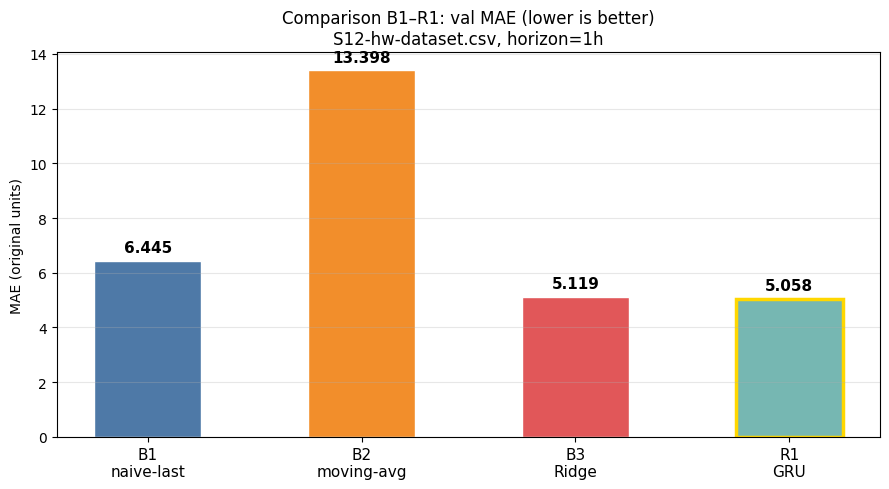

In [26]:
# baselines_compare.png
exp_names = ['B1\nnaive-last', 'B2\nmoving-avg', 'B3\nRidge', 'R1\nGRU']
val_maes  = [mae_b1_val, mae_b2_val, mae_b3_val, mae_r1_val]
colors    = ['#4e79a7','#f28e2b','#e15759','#76b7b2']

x = np.arange(4)
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(x, val_maes, color=colors, width=0.5, edgecolor='white')
for bar, v in zip(bars, val_maes):
    ax.annotate(f'{v:.3f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0,4), textcoords='offset points', ha='center', va='bottom',
                fontsize=11, weight='bold')
ax.set_title('Comparison B1–R1: val MAE (lower is better)\nS12-hw-dataset.csv, horizon=1h', fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(exp_names, fontsize=11)
ax.set_ylabel('MAE (original units)'); ax.grid(axis='y', alpha=0.3)
best_idx = val_maes.index(min(val_maes))
bars[best_idx].set_edgecolor('gold'); bars[best_idx].set_linewidth(2.5)
plt.tight_layout()
plt.savefig(f'{ART}/figures/baselines_compare.png', dpi=100, bbox_inches='tight')
plt.show()

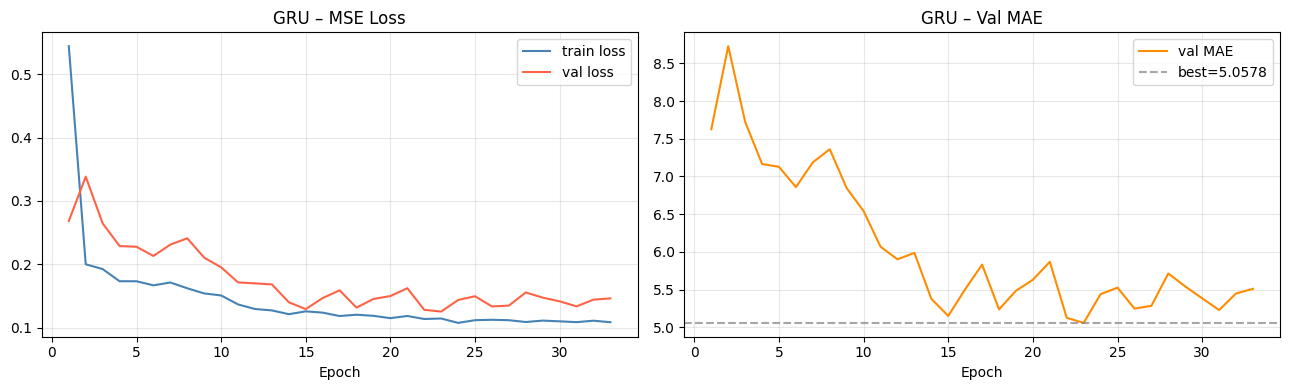

In [27]:
# gru_learning_curves.png
eps = range(1, len(history_gru['train_loss'])+1)
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(13,4))
ax1.plot(eps, history_gru['train_loss'], label='train loss', color='steelblue')
ax1.plot(eps, history_gru['val_loss'],   label='val loss',   color='tomato')
ax1.set_title('GRU – MSE Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(eps, history_gru['val_mae'], label='val MAE', color='darkorange')
ax2.axhline(best_val_mae, linestyle='--', color='gray', alpha=0.7, label=f'best={best_val_mae:.4f}')
ax2.set_title('GRU – Val MAE'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ART}/figures/gru_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

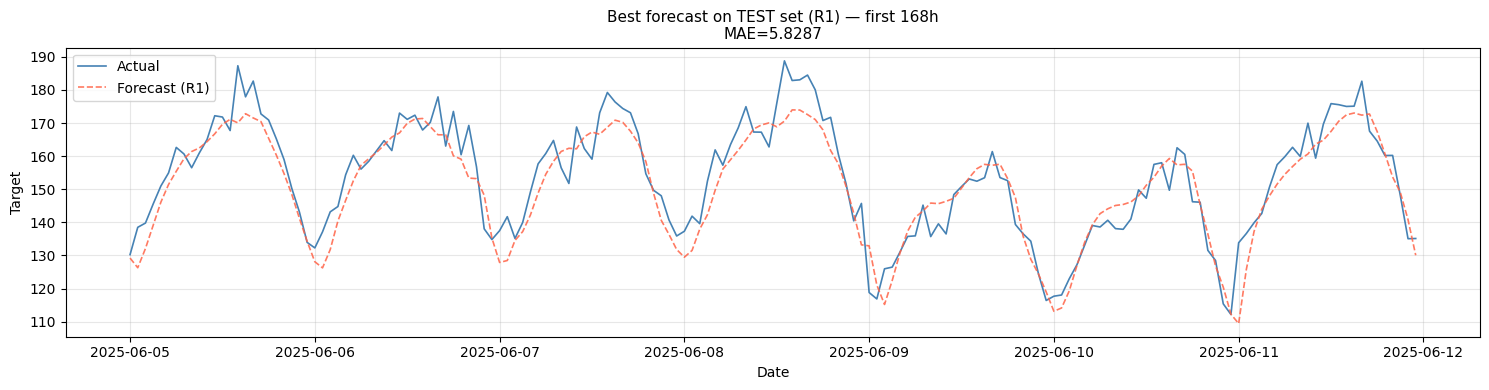

In [28]:
# best_forecast_test.png — лучший подход на test
# Определяем pred и true для лучшего подхода
if best_approach == 'B1':
    y_pred_best_test = pred_b1_test; y_true_best_test = test_series
    test_dates = df_test['date'].values
elif best_approach == 'B2':
    y_pred_best_test = pred_b2_test; y_true_best_test = test_series[:len(pred_b2_test)]
    test_dates = df_test['date'].values[:len(pred_b2_test)]
elif best_approach == 'B3':
    y_pred_best_test = pred_b3_test; y_true_best_test = y_test_f
    test_dates = df_feat_clean.loc[test_mask, 'date'].values
else:  # R1
    y_pred_best_test = pred_r1_test; y_true_best_test = true_r1_test
    test_dates = df.iloc[n_train + n_val + WINDOW_SIZE : n_train + n_val + WINDOW_SIZE + len(pred_r1_test)]['date'].values

# Берём первые 7 дней (168 часов) для читаемого графика
SHOW = min(168, len(y_true_best_test))
fig, ax = plt.subplots(figsize=(15,4))
ax.plot(test_dates[:SHOW], y_true_best_test[:SHOW], label='Actual',    color='steelblue', linewidth=1.2)
ax.plot(test_dates[:SHOW], y_pred_best_test[:SHOW], label=f'Forecast ({best_approach})',
        color='tomato', linewidth=1.2, linestyle='--', alpha=0.85)
ax.set_title(f'Best forecast on TEST set ({best_approach}) — first {SHOW}h\n'
             f'MAE={mae_r1_test if best_approach=="R1" else eval(f"mae_{best_approach.lower()}_test"):.4f}', fontsize=11)
ax.set_xlabel('Date'); ax.set_ylabel('Target')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{ART}/figures/best_forecast_test.png', dpi=100, bbox_inches='tight')
plt.show()

In [29]:
print('\n=== ФИНАЛЬНАЯ СВОДКА ===')
print(f'Датасет: S12-hw-dataset.csv  |  {N} наблюдений  |  2025-01-01 → 2025-06-29  |  hourly')
print(f'Temporal split: train={n_train} / val={n_val} / test={n_test}')
print()
print('Val MAE:  B1={:.4f}  B2={:.4f}  B3={:.4f}  R1={:.4f}'.format(
      mae_b1_val, mae_b2_val, mae_b3_val, mae_r1_val))
print('Val RMSE: B1={:.4f}  B2={:.4f}  B3={:.4f}  R1={:.4f}'.format(
      rmse_b1_val, rmse_b2_val, rmse_b3_val, rmse_r1_val))
print('Val MAPE: B1={:.2f}%  B2={:.2f}%  B3={:.2f}%  R1={:.2f}%'.format(
      mape_b1_val, mape_b2_val, mape_b3_val, mape_r1_val))
print()
print(f'Лучший по val_MAE: {best_approach}')
print(f'Test MAE={mae_r1_test:.4f}  RMSE={rmse_r1_test:.4f}  MAPE={mape_r1_test:.2f}% (R1)')
print()
print('Обсуждение утечек:')
print('  1) lag/rolling признаки строились через .shift(1) — текущее значение не включается.')
print('  2) StandardScaler обучался только на train-части.')
print('  3) Выбор гиперпараметров по val, тест — один раз в конце.')
print('  4) MA forecast: история берётся только из прошлого.')


=== ФИНАЛЬНАЯ СВОДКА ===
Датасет: S12-hw-dataset.csv  |  4320 наблюдений  |  2025-01-01 → 2025-06-29  |  hourly
Temporal split: train=3024 / val=648 / test=648

Val MAE:  B1=6.4448  B2=13.3980  B3=5.1194  R1=5.0578
Val RMSE: B1=8.2010  B2=16.1699  B3=6.4184  R1=6.5383
Val MAPE: B1=4.40%  B2=9.20%  B3=3.39%  R1=3.41%

Лучший по val_MAE: R1
Test MAE=5.8287  RMSE=7.3975  MAPE=3.75% (R1)

Обсуждение утечек:
  1) lag/rolling признаки строились через .shift(1) — текущее значение не включается.
  2) StandardScaler обучался только на train-части.
  3) Выбор гиперпараметров по val, тест — один раз в конце.
  4) MA forecast: история берётся только из прошлого.
